In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder,
    LabelBinarizer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv("k_d2.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (120, 25)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,209,19.0,70.0,1.020,0.0,0.0,NaN,normal,notpresent,notpresent,...,11.5,NaN,6900.0,NaN,no,no,no,good,no,no
1,280,47.0,80.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,13.3,52,8100.0,5.2,no,no,no,good,no,no
2,33,60.0,100.0,1.020,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,10.1,29,NaN,NaN,yes,no,no,poor,no,no
3,210,59.0,100.0,1.015,4.0,2.0,normal,normal,notpresent,notpresent,...,7.3,20,9800.0,3.9,yes,yes,yes,good,no,yes
4,93,73.0,100.0,1.010,3.0,2.0,abnormal,abnormal,present,notpresent,...,9.2,30,7000.0,3.2,yes,yes,yes,poor,no,no


In [3]:
# ==============================
# 3. EXPLORATORY DATA ANALYSIS
# ==============================

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,209,19.0,70.0,1.020,0.0,0.0,NaN,normal,notpresent,notpresent,...,11.5,NaN,6900.0,NaN,no,no,no,good,no,no
1,280,47.0,80.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,13.3,52,8100.0,5.2,no,no,no,good,no,no
2,33,60.0,100.0,1.020,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,10.1,29,NaN,NaN,yes,no,no,poor,no,no
3,210,59.0,100.0,1.015,4.0,2.0,normal,normal,notpresent,notpresent,...,7.3,20,9800.0,3.9,yes,yes,yes,good,no,yes
4,93,73.0,100.0,1.010,3.0,2.0,abnormal,abnormal,present,notpresent,...,9.2,30,7000.0,3.2,yes,yes,yes,poor,no,no



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      120 non-null    int64  
 1   age     116 non-null    float64
 2   bp      117 non-null    float64
 3   sg      109 non-null    float64
 4   al      109 non-null    float64
 5   su      109 non-null    float64
 6   rbc     75 non-null     str    
 7   pc      105 non-null    str    
 8   pcc     120 non-null    str    
 9   ba      120 non-null    str    
 10  bgr     109 non-null    float64
 11  bu      115 non-null    float64
 12  sc      115 non-null    float64
 13  sod     100 non-null    float64
 14  pot     100 non-null    float64
 15  hemo    107 non-null    float64
 16  pcv     101 non-null    str    
 17  wc      92 non-null     float64
 18  rc      83 non-null     float64
 19  htn     119 non-null    str    
 20  dm      119 non-null    str    
 21  cad     119 non-null    str 

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,wc,rc
count,120.000000,116.000000,117.000000,109.000000,109.00000,109.000000,109.000000,115.000000,115.000000,100.00000,100.000000,107.000000,92.000000,83.000000
mean,191.500000,51.551724,77.435897,1.017339,1.00000,0.477064,143.165138,58.447826,3.226957,138.11000,4.358000,12.514953,8518.478261,4.709639
std,123.781184,16.494186,12.258273,0.005675,1.30526,1.159473,83.641709,48.429293,5.500659,6.99624,0.856488,2.992658,2563.691078,1.022624
min,0.000000,5.000000,50.000000,1.005000,0.00000,0.000000,22.000000,1.500000,0.500000,111.00000,2.500000,4.800000,2600.000000,2.100000
25%,77.750000,42.000000,70.000000,1.015000,0.00000,0.000000,95.000000,25.000000,0.900000,135.00000,3.700000,10.250000,6775.000000,3.950000
50%,180.500000,54.500000,80.000000,1.020000,0.00000,0.000000,113.000000,46.000000,1.200000,139.00000,4.350000,12.600000,8300.000000,4.800000
75%,292.500000,63.000000,90.000000,1.020000,2.00000,0.000000,141.000000,72.000000,3.050000,142.00000,4.900000,15.100000,9900.000000,5.200000
max,396.000000,82.000000,110.000000,1.025000,4.00000,5.000000,490.000000,235.000000,48.100000,150.00000,7.600000,17.800000,19100.000000,6.500000



Column Names:
['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [4]:
data = df.dropna()

In [5]:
# ==============================
# 4. MISSING VALUES
# ==============================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
id        0
age       4
bp        3
sg       11
al       11
su       11
rbc      45
pc       15
pcc       0
ba        0
bgr      11
bu        5
sc        5
sod      20
pot      20
hemo     13
pcv      19
wc       28
rc       37
htn       1
dm        1
cad       1
appet     1
pe        1
ane       1
dtype: int64

Total missing values: 264


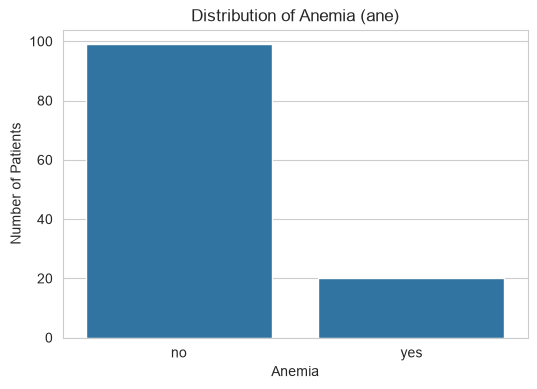

In [6]:
# ==============================
# 5. TARGET VARIABLE
# ==============================

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))

sns.countplot(x="ane", data=df)

plt.title("Distribution of Anemia (ane)")
plt.xlabel("Anemia")
plt.ylabel("Number of Patients")

plt.show()

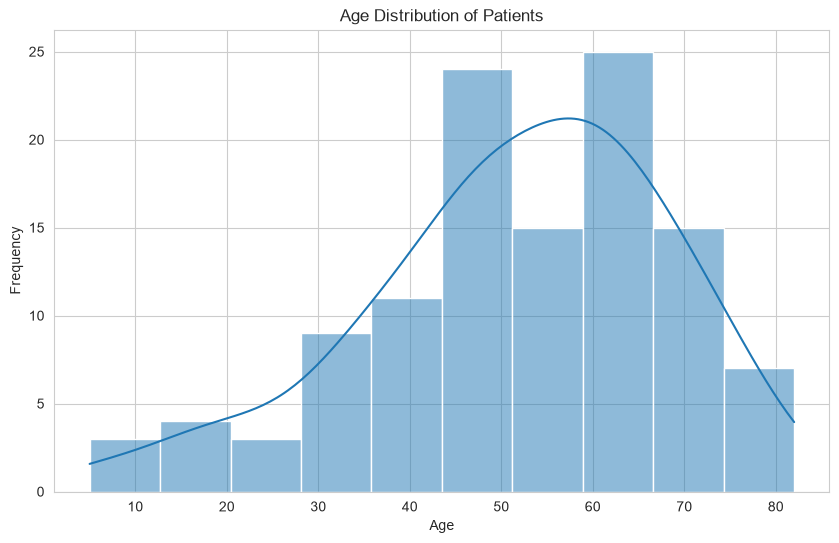

In [7]:
# ==============================
# 6. AGE DISTRIBUTION
# ==============================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["age"],
    kde=True,
    bins=10
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

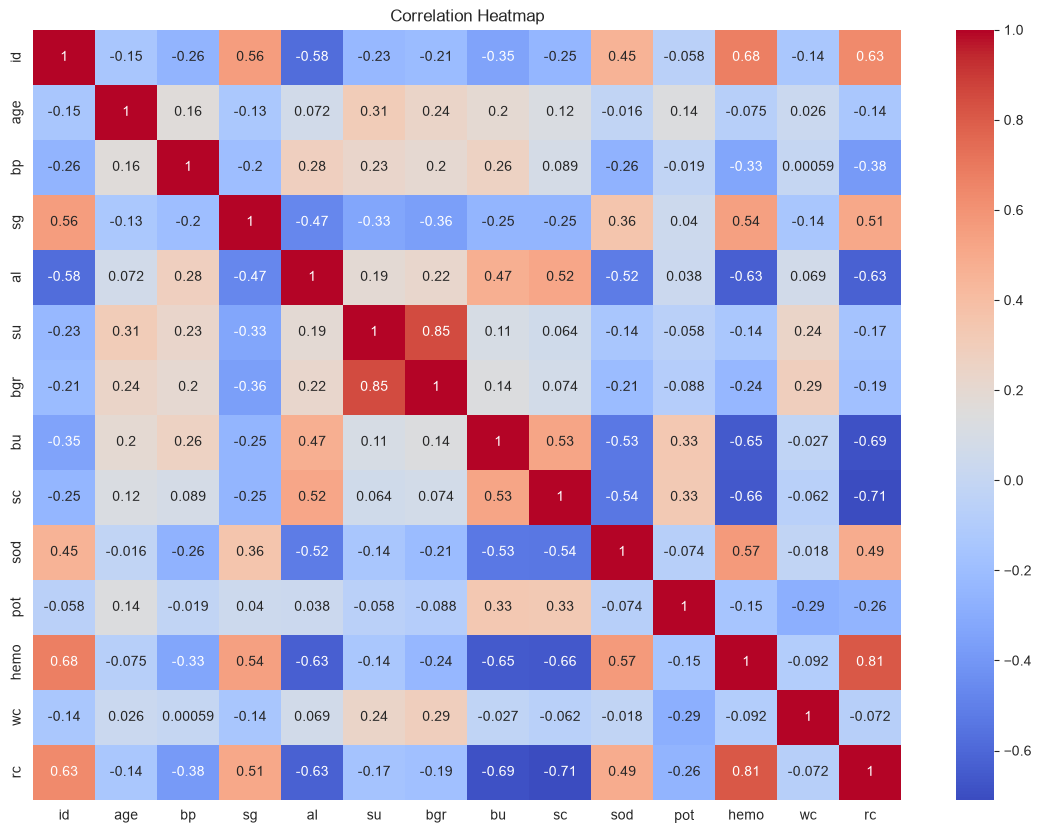

In [8]:
# ==============================
# 7. CORRELATION HEATMAP
# ==============================

numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
# ==============================
# 8. FEATURES AND TARGET
# ==============================

# Remove rows where the target variable is missing
df_model = df.dropna(subset=["ane"]).copy()

# Remove ID because it is only an identifier
X = df_model.drop(columns=["ane", "id"])

# Target variable
y = df_model["ane"]

print("Dataset shape after removing missing target:")
print(df_model.shape)

print("\nTarget distribution:")
print(y.value_counts())

Dataset shape after removing missing target:
(119, 25)

Target distribution:
ane
no     99
yes    20
Name: count, dtype: int64


In [10]:
# ==============================
# 9. ENCODE TARGET VARIABLE
# ==============================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("Encoded target values:")
print(np.unique(y))

print("\nMapping:")

for original, encoded in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(original, "->", encoded)
    print(original, "->", encoded)

Encoded target values:
[0 1]

Mapping:
no -> 0
no -> 0
yes -> 1
yes -> 1


In [11]:
# ==============================
# 10. IDENTIFY FEATURE TYPES
# ==============================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc', 'rc']

Categorical features:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'htn', 'dm', 'cad', 'appet', 'pe']


In [12]:
# ==============================
# 11. PREPROCESSING
# ==============================

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
# ==============================
# 12. TRAIN TEST SPLIT
# ==============================

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 95
Testing samples: 24


In [14]:
# ==============================
# 13. CLASSIFICATION MODELS
# ==============================

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [15]:
# ==============================
# 14. TRAIN AND EVALUATE MODELS
# ==============================

results = {}

trained_models = {}

for name, classifier in classifiers.items():

    # Create pipeline
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    # Train
    model.fit(X_train, Y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(
        Y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        Y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        Y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results[name] = accuracy
    trained_models[name] = model

    print("=" * 70)
    print(name)

    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            Y_test,
            y_pred,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, y_pred))

Logistic Regression
Accuracy : 79.17%
Precision: 0.8123
Recall   : 0.7917
F1 Score : 0.8006

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.40      0.50      0.44         4

    accuracy                           0.79        24
   macro avg       0.65      0.68      0.66        24
weighted avg       0.81      0.79      0.80        24

Confusion Matrix:
[[17  3]
 [ 2  2]]
Decision Tree
Accuracy : 79.17%
Precision: 0.8123
Recall   : 0.7917
F1 Score : 0.8006

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.40      0.50      0.44         4

    accuracy                           0.79        24
   macro avg       0.65      0.68      0.66        24
weighted avg       0.81      0.79      0.80        24

Confusion Matrix:
[[17  3]
 [ 2  2]]
Random Forest
Accuracy : 87.50%
Precision: 0.8

In [16]:
# ==============================
# 15. MODEL COMPARISON
# ==============================

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100

display(results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
))

,Model,Accuracy,Accuracy (%)
2,Random Forest,0.875000,87.500000
3,Support Vector Machine,0.875000,87.500000
0,Logistic Regression,0.791667,79.166667
1,Decision Tree,0.791667,79.166667
4,Naive Bayes,0.541667,54.166667


In [17]:
# ==============================
# 16. BEST CLASSIFIER
# ==============================

best_classifier_name = max(
    results,
    key=results.get
)

best_accuracy = results[best_classifier_name]

print("Best Classifier:", best_classifier_name)
print(f"Accuracy: {best_accuracy * 100:.2f}%")

Best Classifier: Random Forest
Accuracy: 87.50%


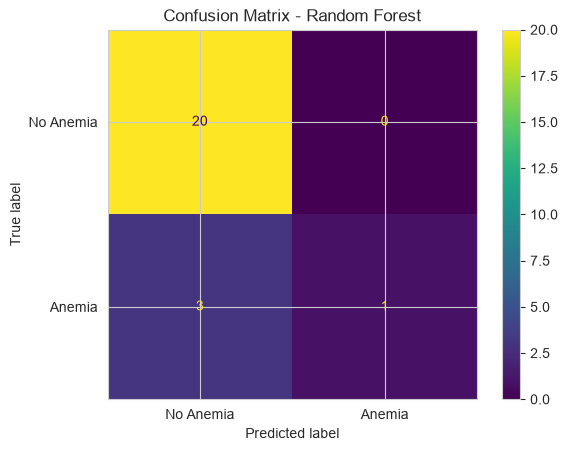

In [18]:
# ==============================
# 17. CONFUSION MATRIX
# ==============================

best_model = trained_models[best_classifier_name]

best_predictions = best_model.predict(X_test)

cm = confusion_matrix(
    Y_test,
    best_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Anemia", "Anemia"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_classifier_name}"
)

plt.show()

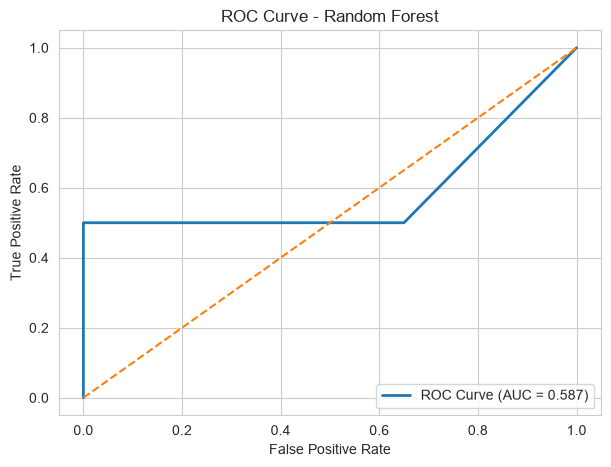

AUC: 0.5874999999999999


In [19]:
# ==============================
# 18. ROC CURVE AND AUC
# ==============================

y_pred_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    Y_test,
    y_pred_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve - {best_classifier_name}"
)

plt.legend(
    loc="lower right"
)

plt.show()

print("AUC:", roc_auc)

In [20]:
# ==============================
# 19. LOGISTIC REGRESSION
#     HYPERPARAMETER TUNING
# ==============================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=2000)
        )
    ]
)

param_grid_lr = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"]
}

grid_search_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy"
)

grid_search_lr.fit(X_train, Y_train)

print("Best Logistic Regression Parameters:")
print(grid_search_lr.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search_lr.best_score_)

lr_best_model = grid_search_lr.best_estimator_

Best Logistic Regression Parameters:
{'classifier__C': 10, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}

Best Cross-Validation Score:
0.9578947368421054


In [21]:
# ==============================
# 20. TUNED LOGISTIC REGRESSION
# ==============================

y_pred_lr = lr_best_model.predict(X_test)

print("Logistic Regression - Tuned Model")

print(
    f"Accuracy: "
    f"{accuracy_score(Y_test, y_pred_lr):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(Y_test, y_pred_lr, average='weighted', zero_division=0):.4f}"
)

print(
    f"Recall: "
    f"{recall_score(Y_test, y_pred_lr, average='weighted', zero_division=0):.4f}"
)

print(
    f"F1 Score: "
    f"{f1_score(Y_test, y_pred_lr, average='weighted', zero_division=0):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_lr))

Logistic Regression - Tuned Model
Accuracy: 0.7500
Precision: 0.7963
Recall: 0.7500
F1 Score: 0.7684

Confusion Matrix:
[[16  4]
 [ 2  2]]


In [22]:
# ==============================
# 21. DECISION TREE
#     HYPERPARAMETER TUNING
# ==============================

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(random_state=42)
        )
    ]
)

param_grid_dt = {
    "classifier__max_depth": [
        None, 3, 4, 5, 6, 7
    ],
    "classifier__min_samples_split": [
        2, 5, 7
    ],
    "classifier__min_samples_leaf": [
        1, 2, 4
    ],
    "classifier__criterion": [
        "gini",
        "entropy"
    ]
}

grid_search_dt = GridSearchCV(
    decision_tree_pipeline,
    param_grid_dt,
    cv=5,
    scoring="accuracy",
    verbose=1
)

grid_search_dt.fit(X_train, Y_train)

print("Best Decision Tree Parameters:")
print(grid_search_dt.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search_dt.best_score_)

dt_best_model = grid_search_dt.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Decision Tree Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best Cross-Validation Score:
0.9263157894736842


In [23]:
# ==============================
# 22. EVALUATE DECISION TREE
# ==============================

y_pred_dt = dt_best_model.predict(X_test)

print("Decision Tree - Tuned Model")

print(
    f"Accuracy: "
    f"{accuracy_score(Y_test, y_pred_dt):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(Y_test, y_pred_dt, average='weighted', zero_division=0):.4f}"
)

print(
    f"Recall: "
    f"{recall_score(Y_test, y_pred_dt, average='weighted', zero_division=0):.4f}"
)

print(
    f"F1 Score: "
    f"{f1_score(Y_test, y_pred_dt, average='weighted', zero_division=0):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_dt))

Decision Tree - Tuned Model
Accuracy: 0.7917
Precision: 0.8123
Recall: 0.7917
F1 Score: 0.8006

Confusion Matrix:
[[17  3]
 [ 2  2]]


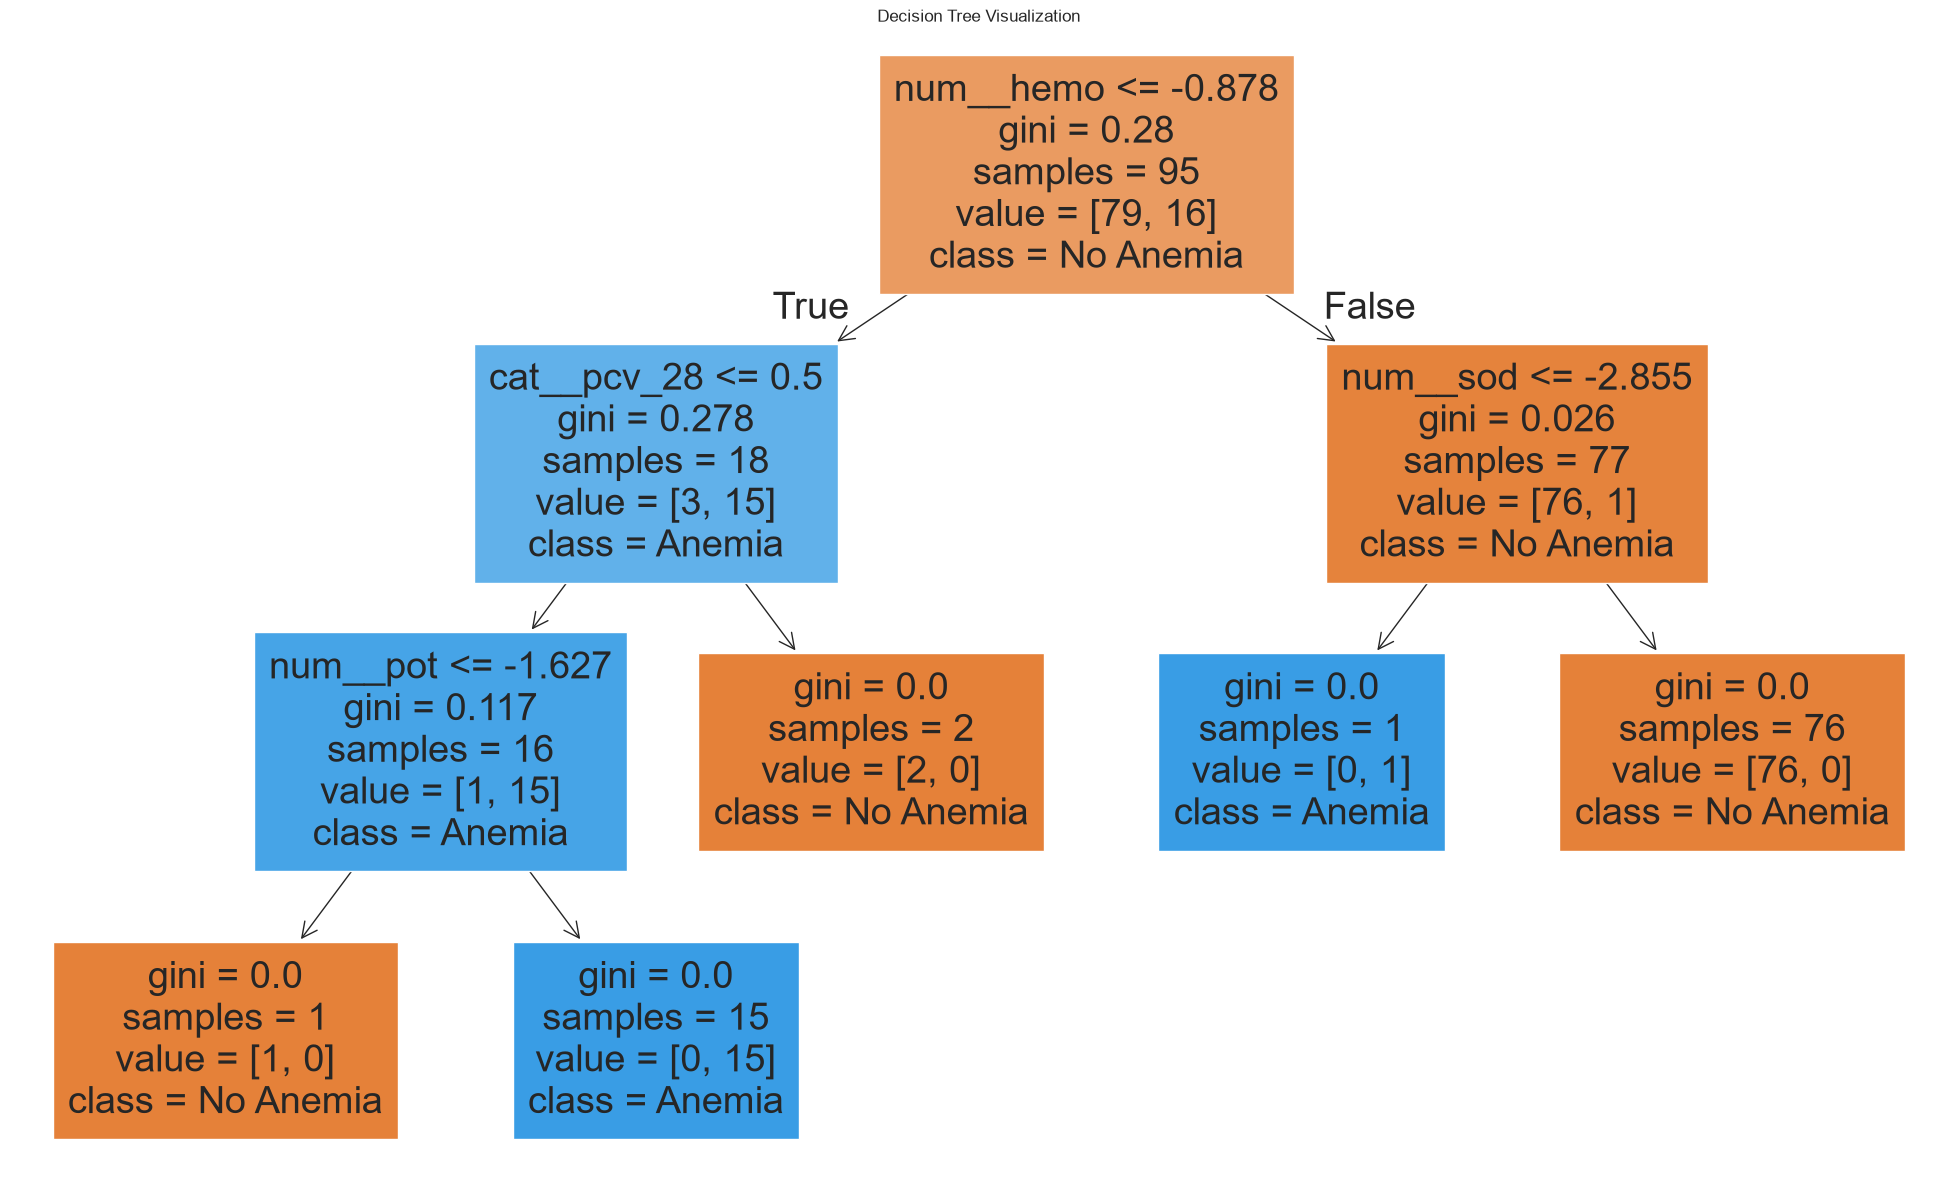

In [24]:
# ==============================
# 23. DECISION TREE VISUALIZATION
# ==============================

# Get the preprocessor
dt_preprocessor = dt_best_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = dt_preprocessor.get_feature_names_out()

# Get actual decision tree
dt_classifier = dt_best_model.named_steps["classifier"]

plt.figure(figsize=(25, 15))

plot_tree(
    dt_classifier,
    feature_names=feature_names,
    class_names=["No Anemia", "Anemia"],
    filled=True,
    max_depth=4
)

plt.title("Decision Tree Visualization")

plt.show()

In [25]:
# ==============================
# 24. ADABOOST CLASSIFIER
# ==============================

base_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

adaboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            AdaBoostClassifier(
                estimator=base_dt,
                n_estimators=50,
                random_state=42
            )
        )
    ]
)

adaboost_pipeline.fit(
    X_train,
    Y_train
)

y_pred_ada = adaboost_pipeline.predict(X_test)

In [26]:
# ==============================
# 25. ADABOOST EVALUATION
# ==============================

ada_accuracy = accuracy_score(
    Y_test,
    y_pred_ada
)

ada_precision = precision_score(
    Y_test,
    y_pred_ada,
    average="weighted",
    zero_division=0
)

ada_recall = recall_score(
    Y_test,
    y_pred_ada,
    average="weighted",
    zero_division=0
)

ada_f1 = f1_score(
    Y_test,
    y_pred_ada,
    average="weighted",
    zero_division=0
)

ada_cm = confusion_matrix(
    Y_test,
    y_pred_ada
)

print(f"Accuracy : {ada_accuracy:.4f}")
print(f"Precision: {ada_precision:.4f}")
print(f"Recall   : {ada_recall:.4f}")
print(f"F1 Score : {ada_f1:.4f}")

print("\nConfusion Matrix:")
print(ada_cm)

Accuracy : 0.7917
Precision: 0.8123
Recall   : 0.7917
F1 Score : 0.8006

Confusion Matrix:
[[17  3]
 [ 2  2]]


In [27]:
# ==============================
# 26. ADABOOST FEATURE IMPORTANCE
# ==============================

ada_preprocessor = (
    adaboost_pipeline
    .named_steps["preprocessor"]
)

ada_classifier = (
    adaboost_pipeline
    .named_steps["classifier"]
)

feature_names_ada = (
    ada_preprocessor
    .get_feature_names_out()
)

importances = (
    ada_classifier
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names_ada,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
10,num__hemo,7.379223e-01
29,cat__pcv_28,1.174347e-01
8,num__sod,7.418215e-02
9,num__pot,7.046084e-02
7,num__sc,1.001309e-16
...,...,...
60,cat__cad_yes,0.000000e+00
61,cat__appet_good,0.000000e+00
62,cat__appet_poor,0.000000e+00
63,cat__pe_no,0.000000e+00


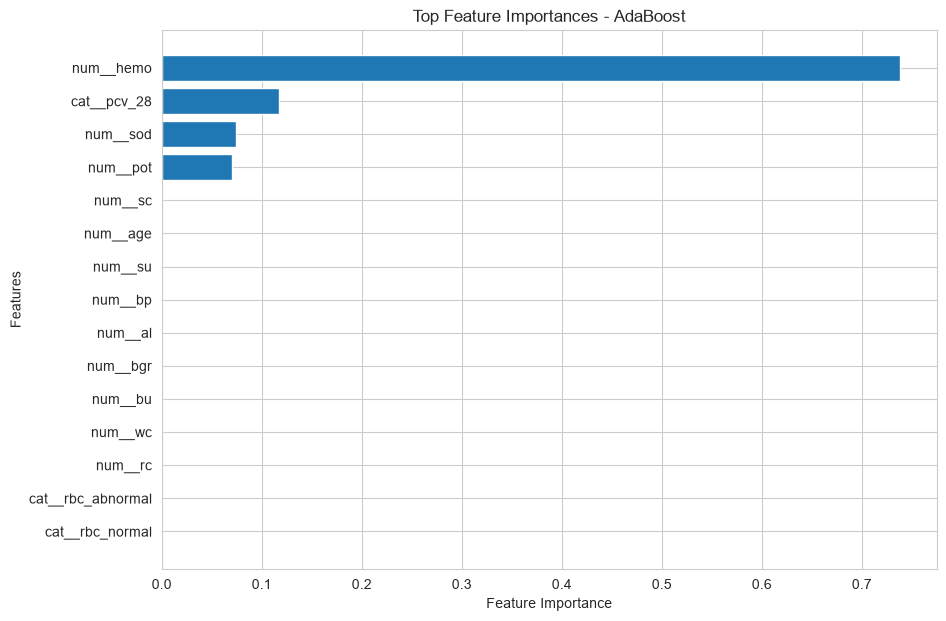

In [28]:
# ==============================
# 27. FEATURE IMPORTANCE PLOT
# ==============================

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.title(
    "Top Feature Importances - AdaBoost"
)

plt.show()

In [29]:
# ==============================
# 28. FINAL MODEL COMPARISON
# ==============================

final_results = {
    "Initial Logistic Regression":
        accuracy_score(
            Y_test,
            trained_models["Logistic Regression"].predict(X_test)
        ),

    "Initial Decision Tree":
        accuracy_score(
            Y_test,
            trained_models["Decision Tree"].predict(X_test)
        ),

    "Initial Random Forest":
        accuracy_score(
            Y_test,
            trained_models["Random Forest"].predict(X_test)
        ),

    "Initial SVM":
        accuracy_score(
            Y_test,
            trained_models["Support Vector Machine"].predict(X_test)
        ),

    "Initial Naive Bayes":
        accuracy_score(
            Y_test,
            trained_models["Naive Bayes"].predict(X_test)
        ),

    "Tuned Logistic Regression":
        accuracy_score(
            Y_test,
            y_pred_lr
        ),

    "Tuned Decision Tree":
        accuracy_score(
            Y_test,
            y_pred_dt
        ),

    "AdaBoost":
        ada_accuracy
}

final_results_df = pd.DataFrame(
    list(final_results.items()),
    columns=["Model", "Accuracy"]
)

final_results_df["Accuracy (%)"] = (
    final_results_df["Accuracy"] * 100
)

display(
    final_results_df.sort_values(
        by="Accuracy (%)",
        ascending=False
    )
)

,Model,Accuracy,Accuracy (%)
3,Initial SVM,0.875000,87.500000
2,Initial Random Forest,0.875000,87.500000
1,Initial Decision Tree,0.791667,79.166667
0,Initial Logistic Regression,0.791667,79.166667
7,AdaBoost,0.791667,79.166667
6,Tuned Decision Tree,0.791667,79.166667
5,Tuned Logistic Regression,0.750000,75.000000
4,Initial Naive Bayes,0.541667,54.166667
